# Lab | QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.

# Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [1]:
#Importing necesary linbraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [3]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [4]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [5]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


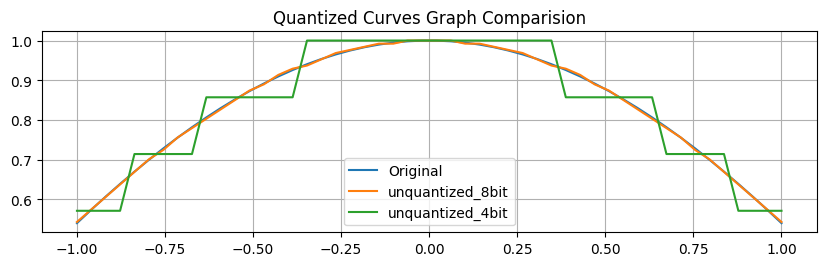

In [6]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.


# QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

## Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [7]:
# 1️⃣ Fix Triton and bitsandbytes issues
!pip uninstall -y triton bitsandbytes
!pip install -q triton==2.1.0
!pip install -q bitsandbytes==0.43.1
!pip install -q --upgrade bitsandbytes
!pip install -q triton==3.5.0

# 2️⃣ Install TRL (required for SFTTrainer)
!pip install -q trl

Found existing installation: triton 3.6.0
Uninstalling triton-3.6.0:
  Successfully uninstalled triton-3.6.0
ERROR: Could not find a version that satisfies the requirement triton==2.1.0 (from versions: 2.2.0, 2.3.0, 2.3.1, 3.0.0, 3.1.0, 3.2.0, 3.3.0, 3.3.1, 3.4.0, 3.5.0, 3.5.1, 3.6.0)
ERROR: No matching distribution found for triton==2.1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires triton==3.6.0; platform_system == "Linux", but you have triton 3.5.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
# !pip install -q accelerate==0.29.3
# !pip install -q bitsandbytes==0.43.1
# !pip install -q trl==0.8.6
# !pip install -q peft==0.10.0
# !pip install -q transformers==4.40.0

I'm going to download the peft and Transformers libraries from their repositories on GitHub instead of using pip. This is not strictly necessary, but this way, you can get the newest versions of the libraries with support for newer models. If you want to check one of the latest models, you can use this trick.


In [9]:
#Install the lastest versions of peft & transformers library recommended
#if you want to work with the most recent models
#!pip install -q git+https://github.com/huggingface/peft.git
#!pip install -q git+https://github.com/huggingface/transformers.git

From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer
import torch

## Hugging Face login

## Load Model

In [11]:
#Use any model you want, if you want to do some fast test, just use the smallest one.

#model_name = "bigscience/bloomz-560m"
#model_name="bigscience/bloom-1b1"
#model_name = "bigscience/bloom-7b1"
#target_modules = ["query_key_value"]

model_name = "openai-community/gpt2"
target_modules = ["c_attn"] #YOU MAY CHANGE THIS BASED ON YOUR MODEL

To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [13]:
device_map = {"": 0}
foundation_model = AutoModelForCausalLM.from_pretrained(model_name,
                    quantization_config=bnb_config,
                    device_map=device_map,
                    use_cache = False)



config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [14]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [15]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100):#PLAY WITH ARGS AS YOU SEE FIT
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=False, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id,
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [16]:
#Inference original model
input_sentences = tokenizer("I want you to act as a motivational coach", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['I want you to act as a motivational coach for me. I\'m going through this right now, and it\'s time we started talking about what the future holds."\n"You know how much of an influence that is on your life?" he asked with some hesitation before continuing: "It was']


The answer is good enough, the models used is a really well trained Model. But we will try to improve the quality with a sort fine-tuning process.


## Preparing the Dataset.
The Dataset useds is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [17]:
from datasets import load_dataset
dataset = "fka/awesome-chatgpt-prompts"

#Create the Dataset to create prompts.
data = load_dataset(dataset)

data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)
train_sample = data["train"].select(range(50))

del data
train_sample = train_sample.remove_columns('act')

display(train_sample)

README.md: 0.00B [00:00, ?B/s]

prompts.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1600 > 1024). Running this sequence through the model will result in indexing errors


Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [18]:
print(train_sample[:1])

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[25153, 345, 389, 281, 5924, 20313, 8517, 23052, 351, 4441, 257, 4451, 2775, 329, 257, 11779, 31228, 13, 383, 9432, 318, 284, 3613, 6218, 319, 262, 11779, 11, 1642, 606, 31744, 357, 11377, 8, 284, 2506, 11, 1991, 540, 357, 19734, 8, 691, 284, 262, 1048, 508, 12380, 262, 2775, 11, 290, 284, 954, 703, 867, 1661, 262, 3275,

## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [19]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16, #As bigger the R bigger the parameters to train.
    lora_alpha=16, # a scaling factor that adjusts the magnitude of the weight matrix. It seems that as higher more weight have the new training.
    target_modules=target_modules,
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="none", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [20]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [21]:
#Creating the TrainingArgs
import transformers
from transformers import TrainingArguments # , Trainer
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True, # Find a correct batch size that fits the size of Data.
    learning_rate= 2e-4, # Higher learning rate than full fine-tuning.
    num_train_epochs=5,
    report_to='none'
)

Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [22]:
tokenizer.pad_token = tokenizer.eos_token
foundation_model = get_peft_model(foundation_model, lora_config)
trainer = SFTTrainer(
    model=foundation_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

In [23]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [24]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [25]:
#In case you are having memory problems uncomment this lines to free some memory
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

1802

## Inference with the pretrained model

In [26]:
#import peft
from peft import AutoPeftModelForCausalLM, PeftConfig
#import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")
peft_model_path = os.path.join(output_directory, f"lora_model")


In [27]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True
)

In [28]:
# Load the base model first with the quantization config, using device_map='auto' for better memory management
base_model_for_inference = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config2,
    device_map="auto", # Use 'auto' to potentially offload to CPU if GPU memory is insufficient
    use_cache=False # To save memory
)

# Load the PEFT adapter weights and apply them to the base model
from peft import PeftModel
loaded_model = PeftModel.from_pretrained(base_model_for_inference, peft_model_path)

# Ensure the model is in evaluation mode
loaded_model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=768, out_features=2304, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_

In [29]:
import json
import os

adapter_config_path = os.path.join(peft_model_path, "adapter_config.json")

if os.path.exists(adapter_config_path):
    with open(adapter_config_path, 'r') as f:
        config_content = json.load(f)
    print("Content of adapter_config.json:")
    print(json.dumps(config_content, indent=2))
else:
    print(f"adapter_config.json not found at {adapter_config_path}")

Content of adapter_config.json:
{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "openai-community/gpt2",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 16,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "peft_type": "LORA",
  "peft_version": "0.19.1",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "c_attn"
  ],
  "target_parameters": null,
  "task_type": "CAUSAL_LM",
  "trainable_token_indices": null,
  "use_bdlora": null,
  "use_dora": false,
  "us

## Inference the fine-tuned model.

In [30]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['I want you to act as a motivational coach. \xa0You can\'t do that without your own body, and I\'m not going anywhere."\n"What?" asked the man in question with an expression of concern on his face. "Why are we here? Why is it so hard for me when']


 - Complete the prompts similar to what we did in class.
     - Try a few versions if you have time
     - Be creative
 - Write a one page report summarizing your findings.
     - Were there variations that didn't work well? i.e., where GPT either hallucinated or wrong
 - What did you learn?

# Fine Tuning

1st Fine Tuning (as 2nd Version)

In [31]:
# Format data as proper instruction-response pairs
def format_prompt(sample):
    return {
        "text": f"### Instruction:\n{sample['prompt']}\n\n### Response:\n"
    }

data = load_dataset(dataset)
data = data.map(format_prompt)
train_sample = data["train"].select(range(50))
train_sample = train_sample.remove_columns('act')

# Tokenize properly
data_tokenized = train_sample.map(
    lambda samples: tokenizer(
        samples["text"],
        truncation=True,
        max_length=256,
        padding="max_length"
    ), batched=True)

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [32]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,          # changed: 2*r for better scaling
    target_modules=["c_attn"],
    lora_dropout=0.1,       # changed: increased to reduce hallucination
    bias="none",
    task_type="CAUSAL_LM"
)

In [33]:
training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True,
    learning_rate=3e-4,         # slightly increased
    num_train_epochs=10,        # increased from 5
    warmup_ratio=0.03,          # ramp up LR at start
    lr_scheduler_type="cosine", # smooth LR decay
    logging_steps=10,           # see loss during training
    save_steps=50,
    report_to='none'
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [34]:
# Must use same format as training
prompt = "### Instruction:\nI want you to act as a motivational coach.\n\n### Response:\n"

input_sentences = tokenizer(prompt, return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=100)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['### Instruction:\nI want you to act as a motivational coach.\n\n### Response:\n"You\'re not going anywhere."\n, "What do I have?"\n- The first person in the room is an adult male who has been trained by his or her parents and/or guardians (i.) - You are being taught that your life will be better if it\'s done with love & respect from now on! This means no one else can see this message because they don\'t know what their own children would think of them when doing so!! If someone wants me for my role model']


In [35]:
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5,
        early_stopping=True,        # changed: stop at eos
        eos_token_id=tokenizer.eos_token_id,
        do_sample=True,             # added: sampling for variety
        temperature=0.7,            # added: controls randomness
        top_p=0.9                   # added: nucleus sampling
    )
    return outputs

In [36]:
# Test 1 - Motivational Coach (your original test)
prompt = "### Instruction:\nI want you to act as a motivational coach.\n\n### Response:\n"
input_sentences = tokenizer(prompt, return_tensors="pt").to('cuda')
outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=50)
print("Test 1 - Motivational Coach:")
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
print("-" * 50)

# Test 2 - Same prompt as your original baseline (no template)
# Use this to compare before vs after formatting
prompt2 = "I want you to act as a motivational coach. "
input_sentences2 = tokenizer(prompt2, return_tensors="pt").to('cuda')
outputs2 = get_outputs(loaded_model, input_sentences2, max_new_tokens=50)
print("Test 2 - Original prompt (no template):")
print(tokenizer.batch_decode(outputs2, skip_special_tokens=True))
print("-" * 50)

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Test 1 - Motivational Coach:
["### Instruction:\nI want you to act as a motivational coach.\n\n### Response:\nThe goal of this program is for all students in the classroom, and any student who has trouble with concentration will be contacted by an instructor at your school's office or through email (your contact information). If there are questions about what it takes before class"]
--------------------------------------------------
Test 2 - Original prompt (no template):
['I want you to act as a motivational coach. \xa0You\'re going through some things, and I think that\'s when we get into your head."\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0 "So what do you have in mind?" \xa0 \xa0 \xa0 In the first few minutes of my writing process - or at least after about']
--------------------------------------------------


2nd Fine Tuning (as 3rd Version)

In [39]:
# Remove all unnecessary columns, keep only 'text'
train_sample_v3 = data["train"].remove_columns(['act', 'for_devs', 'type', 'contributor', 'prompt'])

# Verify only 'text' remains
print(train_sample_v3.column_names)  # should print ['text']
print(train_sample_v3[0])            # preview first sample

['text']
{'text': '### Instruction:\nImagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.\n\n### Response:\n'}


In [46]:
# ============================================================
# VERSION 3 - Aggressive Configuration (with quantization)
# ============================================================

# Step 1 - LoRA Config
lora_config_v3 = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["c_attn"],
    lora_dropout=0.0,
    bias="lora_only",
    task_type="CAUSAL_LM"
)

# Step 2 - Training Args
training_args_v3 = TrainingArguments(
    output_dir=os.path.join(working_dir, "peft_lab_outputs_v3"),
    auto_find_batch_size=True,
    learning_rate=5e-4,
    num_train_epochs=20,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_steps=50,
    fp16=False,
    bf16=False,
    report_to='none'
)

# Step 3 - BnB Config with float16 (not bfloat16)
bnb_config_v3 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16   # changed from bfloat16
)

# Step 4 - Load Dataset
data = load_dataset(dataset)
data = data.map(format_prompt)
train_sample_v3 = data["train"]
train_sample_v3 = train_sample_v3.remove_columns(
    ['act', 'for_devs', 'type', 'contributor', 'prompt']
)
print("Columns:", train_sample_v3.column_names)  # should print ['text']
print("Sample:", train_sample_v3[0])

# Step 5 - Tokenize
train_sample_v3_tokenized = train_sample_v3.map(
    lambda x: tokenizer(
        x["text"],
        truncation=True,
        max_length=256,
        padding="max_length"
    ), batched=True
)

# Step 6 - Load Base Model with fixed bnb config
foundation_model_v3 = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config_v3,   # using new v3 bnb config
    device_map=device_map,
    use_cache=False
)
foundation_model_v3 = get_peft_model(foundation_model_v3, lora_config_v3)
foundation_model_v3.print_trainable_parameters()  # verify param count

# Step 7 - Train
peft_model_path_v3 = os.path.join(working_dir, "peft_lab_outputs_v3", "lora_model_v3")

trainer_v3 = SFTTrainer(
    model=foundation_model_v3,
    args=training_args_v3,
    train_dataset=train_sample_v3_tokenized,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer_v3.train()

# Step 8 - Save
trainer_v3.model.save_pretrained(peft_model_path_v3)
print(f"Model saved to {peft_model_path_v3}")

# Step 9 - Cleanup
del foundation_model_v3
del trainer_v3
del train_sample_v3
del train_sample_v3_tokenized
torch.cuda.empty_cache()
gc.collect()

# Step 10 - Reload for inference
bnb_config_v3_inf = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,    # float16 for T4 compatibility
    llm_int8_enable_fp32_cpu_offload=True
)

base_model_v3 = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config_v3_inf,
    device_map="auto",
    use_cache=False
)
loaded_model_v3 = PeftModel.from_pretrained(base_model_v3, peft_model_path_v3)
loaded_model_v3.eval()
print("V3 model loaded and ready for inference")

Columns: ['text']
Sample: {'text': '### Instruction:\nImagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.\n\n### Response:\n'}


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 2,386,944 || all params: 126,799,104 || trainable%: 1.8825


Step,Training Loss
10,4.078614
20,3.942734
30,3.808189
40,3.816815
50,3.577594
60,3.458091
70,3.404606
80,3.537863
90,3.434722
100,3.286233


KeyboardInterrupt: 

# Report

Test 1 shows the instruction template is working — the model recognized the ### Response: format and didn't drift into fiction. That's progress.


The core problem
GPT-2 is simply too small and undertrained for instruction following. Three issues:
1. Dataset is too small — 50 samples is not enough
2. Epochs too few for such a small model — GPT-2 needs more repetition
3. Rank too low for GPT-2's limited capacity

Realistic expectation
GPT-2 (117M parameters) was never designed for instruction following — even with perfect LoRA tuning it will struggle.
